O presente trabalho foi desenvolvido a partir de

Inciando através da cinemática diretea, onde buscamos a partir das variáveis do robô encontrar sua posição final.

In [2]:
import DH
import sympy as sp

Construindo o Mecanismo

In [4]:
Planar_2R = [
    {'type': 'revolute', 'a':10, 'alpha': 0, 'd': 0,
     'errors': {'sigma': 0, 'beta': 0, 'epsilon': 0, 'phi': 0,}},

    {'type': 'revolute', 'a':30, 'alpha': 0, 'd': 0,
     'errors': {'sigma': 0, 'beta': 0, 'epsilon': 0, 'phi': 0,}}, 
]

robot = DH.Mechanism(Planar_2R)
# 1. Variáveis fixas
variable_values = {
    robot.theta[0]: (sp.pi/12),   # 15 degrees
    robot.theta[1]: (sp.pi/6),    # 30 degrees
}

# 2. Ranges de movimento
# Define que ambas as juntas podem dar uma volta completa (0 a 2*pi)
ranges_movimento = {
    robot.theta[0]: (0, 2*sp.pi),   
    robot.theta[1]: (0, 2*sp.pi),    
}

Observando o mecanismo exemplo

/home/jvfg/Documents/Robotica/Cinemática/DH_Aplication/venv/lib/python3.12/site-packages/matplotlib/quiver.py:702: RuntimeWarning: divide by zero encountered in scalar divide
  length = a * (widthu_per_lenu / (self.scale * self.width))
/home/jvfg/Documents/Robotica/Cinemática/DH_Aplication/venv/lib/python3.12/site-packages/matplotlib/quiver.py:702: RuntimeWarning: invalid value encountered in multiply
  length = a * (widthu_per_lenu / (self.scale * self.width))


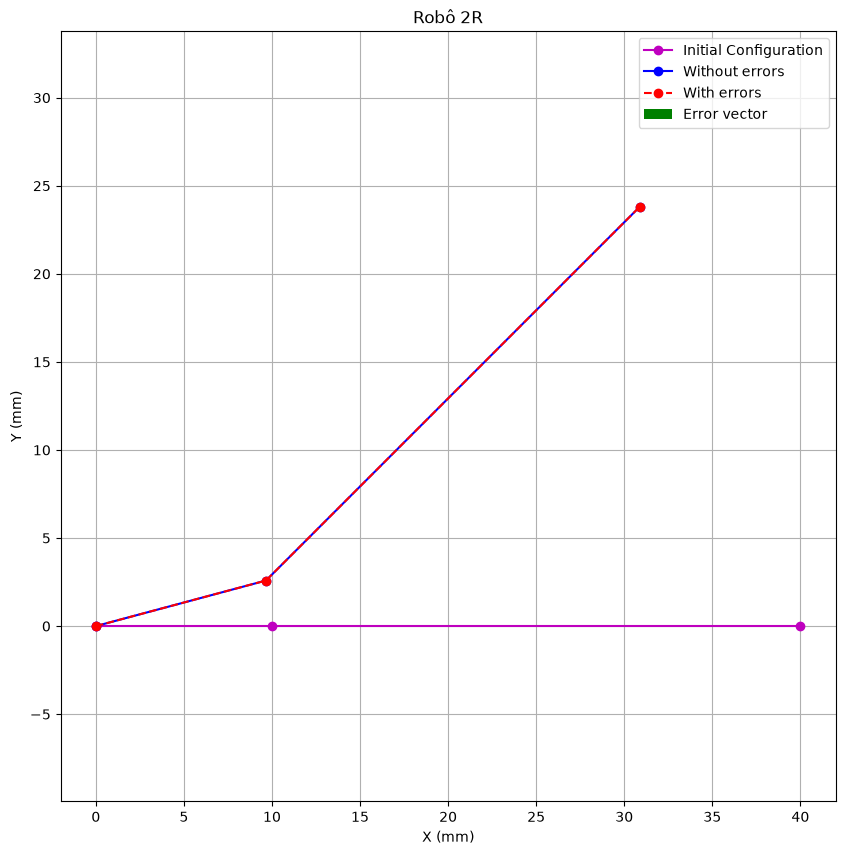

In [ ]:
robot.plot_mechanism(variable_values, title='Robot 2R', plot_type='2d')

A cinemática direta deste mecanismo em termos gerias é dada por:

In [10]:
matrix_g, position_g = robot.forward_kinematics(False)
matrix_g = sp.simplify(matrix_g)

matrix_g_numerical, position_g_numerical, orientation_g_numerical = robot.evaluate_param(matrix_g, variable_values)
print("\nMatrix and position numerical without errors\n") 
print("\nPosition X:\n", position_g_numerical[0])
print("\nPosition y:\n", position_g_numerical[1])
print("\nPosition z:\n", position_g_numerical[2])


Matrix and position numerical without errors


Position X:
 30.872461698487108

Position y:
 23.801393886621632

Position z:
 0.0


Entendendo seu espaço de trabalho

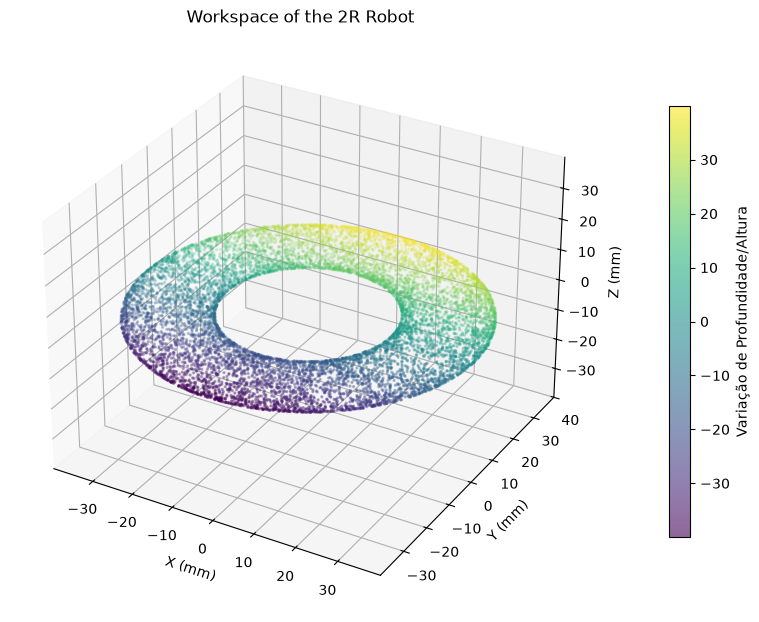

In [6]:
robot.plot_workspace(
        joint_ranges=ranges_movimento, 
        num_samples=10000, 
        title='Workspace of the 2R Robot'
    )